# Week 8: Deep Learning 

## References & Resources

This week covers foundational deep learning concepts inspired by:
- **MIT 6.S191**: Introduction to Deep Learning
- **Stanford CS231n**: Convolutional Neural Networks for Visual Recognition  
- **Stanford CS224n**: Natural Language Processing with Deep Learning
- **Goodfellow et al.**: "Deep Learning" (MIT Press) - The canonical reference
- **Chollet**: "Deep Learning with Python" - Practical implementation guide

## Key Concepts

### 1. Universal Approximation Theorem

Theorem: A feedforward neural network with one hidden layer containing a finite number of neurons can approximate any continuous function on a compact domain.

Implication: MLPs are theoretically powerful enough for any problem, but practical depth helps:
- Shallow networks: Need exponentially many neurons
- Deep networks: Require fewer total parameters (exponential efficiency gain)

### 2. Gradient Descent & Backpropagation

Chain Rule: For y = f(g(x)), dy/dx = (dy/dg)(dg/dx)

Backpropagation: Efficient computation of gradients by applying chain rule backward through network layers:
- Forward pass:  x → layer1 → layer2 → ... → output
- Backward pass: ∇output ← ∇layer2 ← ∇layer1 ← x

### 3. Vanishing/Exploding Gradients

Problem: In deep networks, gradients propagate backward through many layers:
- Vanishing: Gradients become very small (σ'(z) ≤ 0.25), making early layers learn slowly
- Exploding: Gradients become very large, causing instability

Solutions:
- Batch Normalization: Normalize activations to mean=0, std=1
- Residual Connections (ResNet): Skip connections let gradients flow directly
- LSTM/GRU gates: Explicitly control information flow
- Gradient Clipping: Clip large gradients to [-c, c]

### 4. Optimization Algorithms

Stochastic Gradient Descent (SGD):
- θ := θ - lr · ∇L(θ)
- Simple but noisy and slow convergence

Momentum:
- v := β·v - lr·∇L(θ)
- θ := θ + v
- Accelerate convergence by accumulating velocity

Adam (Adaptive Moment Estimation):
- Combine momentum + RMSprop (adaptive learning rates)
- Most popular modern optimizer
- Formula: θ := θ - lr · m̂_t / (√v̂_t + ε)

## Activation Functions

| Activation | Formula | Range | Pros | Cons |
|---|---|---|---|---|
| Sigmoid | σ(z) = 1/(1+e^-z) | (0,1) | Interpretable probability | Vanishing gradients |
| ReLU | f(z) = max(0,z) | [0,∞) | Fast, prevent saturation | Dead neurons, not differentiable at 0 |
| Tanh | tanh(z) = (e^z - e^-z)/(e^z + e^-z) | (-1,1) | Zero-centered | Vanishing gradients |
| Leaky ReLU | f(z) = max(αz, z), α≈0.01 | (-∞,∞) | Prevent dead neurons | Slightly slower |
| ELU | f(z) = z if z>0, α(e^z-1) if z≤0 | (-α,∞) | Smooth, mean≈0 | Slightly slower |

Recommendation: Start with ReLU for hidden layers, sigmoid for binary classification output

## Regularization Techniques

### Overfitting Problem

A model that fits training data too well fails on test data because it memorizes noise rather than learning patterns:
- Underfitting:    Bias ↑, Variance ↓  → Poor on train & test
- Good fit:        Bias ~, Variance ~  → Good on both
- Overfitting:     Bias ↓, Variance ↑  → Good on train, poor on test

### L1/L2 Regularization

L2 Regularization (Weight Decay):
- Loss = MSE + λ·Σ(w²)
- Penalize large weights uniformly
- All weights shrink toward zero

L1 Regularization (Lasso):
- Loss = MSE + λ·Σ|w|
- Create sparsity (exactly zero weights)
- Feature selection

### Dropout (Thinned Networks)

Idea: During training, randomly deactivate neurons with probability p.

- Force network to learn redundant representations
- At test time, use all neurons but scale by (1-p)
- Equivalent to averaging exponentially-many thinned networks

Effect: Act as ensemble of thinned networks → Reduce overfitting

### Early Stopping

Monitor validation loss during training:
- If validation loss increases for N consecutive epochs → Stop
- Prevent memorizing noise
- Simple but effective

### Batch Normalization

- Normalize layer inputs to N(0,1) → Stable gradients
- Higher learning rates possible
- Act as regularizer (add noise during training)
- Reduce internal covariate shift

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
df.drop(columns=['time'], inplace=True)
df_features = df.iloc[:, :-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [3]:
feature_names = X.columns
feature_names

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='str')

In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Multi-Layer Perceptron (MLP)

Epoch 50/500, Train Loss: 0.5626, Val Loss: 0.5621, Test Loss: 0.5826, Train Acc: 0.6926, Val Acc: 0.6985, Test Acc: 0.6889
Epoch 100/500, Train Loss: 0.5219, Val Loss: 0.5058, Test Loss: 0.5905, Train Acc: 0.7440, Val Acc: 0.7560, Test Acc: 0.7222
Epoch 150/500, Train Loss: 0.5046, Val Loss: 0.4895, Test Loss: 0.6282, Train Acc: 0.7512, Val Acc: 0.7847, Test Acc: 0.6222
Epoch 200/500, Train Loss: 0.4912, Val Loss: 0.4952, Test Loss: 0.6575, Train Acc: 0.7620, Val Acc: 0.7605, Test Acc: 0.6667
Epoch 250/500, Train Loss: 0.4600, Val Loss: 0.4564, Test Loss: 0.5934, Train Acc: 0.7883, Val Acc: 0.8230, Test Acc: 0.6889
Epoch 300/500, Train Loss: 0.4298, Val Loss: 0.4198, Test Loss: 0.6000, Train Acc: 0.8062, Val Acc: 0.8278, Test Acc: 0.6889
Epoch 350/500, Train Loss: 0.4369, Val Loss: 0.4077, Test Loss: 0.6388, Train Acc: 0.8170, Val Acc: 0.8279, Test Acc: 0.7333
Epoch 400/500, Train Loss: 0.4336, Val Loss: 0.4122, Test Loss: 0.6310, Train Acc: 0.8289, Val Acc: 0.8230, Test Acc: 0.7444
E

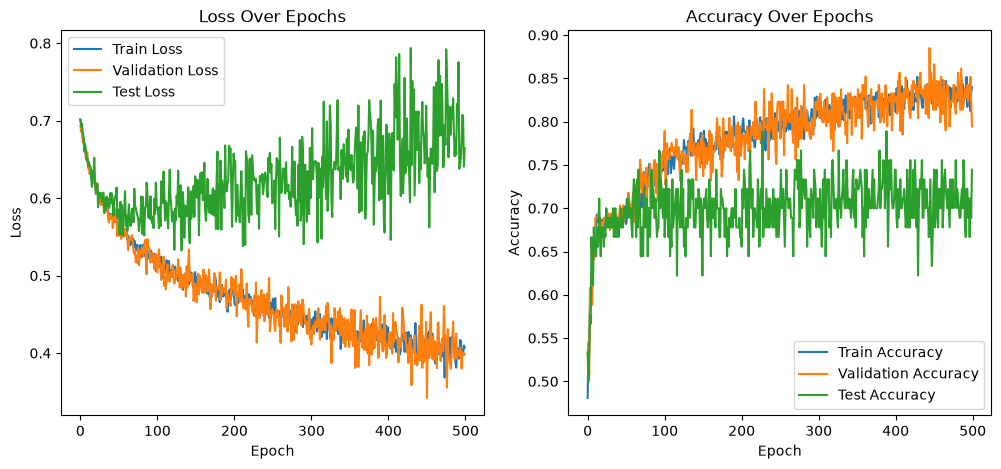

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

class MLPTrainer:
    def __init__(self, input_dim, hidden1=16, hidden2=8, dropout=0.3, lr=0.001, k_folds=5, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._build_model(input_dim, hidden1, hidden2, dropout).to(self.device)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.k_folds = k_folds

        # For tracking
        self.train_losses, self.val_losses, self.test_losses = [], [], []
        self.train_accs, self.val_accs, self.test_accs = [], [], []

    class MLP(nn.Module):
        def __init__(self, input_dim, hidden1=16, hidden2=8, dropout=0.3):
            super().__init__()
            # Hidden layers
            self.layer1 = nn.Linear(input_dim, hidden1)
            self.bn1 = nn.BatchNorm1d(hidden1)
            self.layer2 = nn.Linear(hidden1, hidden2)
            self.bn2 = nn.BatchNorm1d(hidden2)
            self.dropout = nn.Dropout(dropout)
            # Output layer
            self.output = nn.Linear(hidden2, 1)

        def forward(self, x):
            # Hidden layer 1
            x = self.layer1(x)
            x = self.bn1(x)
            x = torch.sigmoid(x)
            x = self.dropout(x)

            # Hidden layer 2
            x = self.layer2(x)
            x = self.bn2(x)
            x = torch.sigmoid(x)
            x = self.dropout(x)

            # Output layer (no dropout)
            x = self.output(x)
            x = torch.sigmoid(x)
            return x
        
    def _build_model(self, input_dim, hidden1, hidden2, dropout):
        return self.MLP(input_dim, hidden1, hidden2, dropout)

    @staticmethod
    def compute_accuracy(y_true, y_pred):
        y_pred_labels = (y_pred >= 0.5).float()
        correct = (y_pred_labels == y_true).float().sum()
        return (correct / y_true.shape[0]).item()

    def fit(self, X_train, y_train, X_test, y_test, epochs=500):
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(self.device)

        for epoch in range(epochs):
            skf = StratifiedKFold(n_splits=self.k_folds, shuffle=True, random_state=42)
            fold_train_losses, fold_val_losses = [], []
            fold_train_accs, fold_val_accs = [], []

            for train_idx, val_idx in skf.split(X_train_tensor, y_train):
                X_fold_train = X_train_tensor[train_idx].to(self.device)
                y_fold_train = y_train_tensor[train_idx].to(self.device)
                X_fold_val = X_train_tensor[val_idx].to(self.device)
                y_fold_val = y_train_tensor[val_idx].to(self.device)

                # Forward pass
                self.optimizer.zero_grad()
                outputs = self.model(X_fold_train)
                loss = self.criterion(outputs, y_fold_train)
                loss.backward()
                self.optimizer.step()

                fold_train_losses.append(loss.item())
                fold_train_accs.append(self.compute_accuracy(y_fold_train, outputs))

                # Validation
                with torch.no_grad():
                    val_outputs = self.model(X_fold_val)
                    val_loss = self.criterion(val_outputs, y_fold_val)
                    fold_val_losses.append(val_loss.item())
                    fold_val_accs.append(self.compute_accuracy(y_fold_val, val_outputs))

            # Record averages
            self.train_losses.append(np.mean(fold_train_losses))
            self.val_losses.append(np.mean(fold_val_losses))
            self.train_accs.append(np.mean(fold_train_accs))
            self.val_accs.append(np.mean(fold_val_accs))

            # Test metrics
            with torch.no_grad():
                test_outputs = self.model(X_test_tensor)
                self.test_losses.append(self.criterion(test_outputs, y_test_tensor).item())
                self.test_accs.append(self.compute_accuracy(y_test_tensor, test_outputs))

            if (epoch+1) % 50 == 0:
                print(
                    f"Epoch {epoch+1}/{epochs}, "
                    f"Train Loss: {self.train_losses[-1]:.4f}, Val Loss: {self.val_losses[-1]:.4f}, Test Loss: {self.test_losses[-1]:.4f}, "
                    f"Train Acc: {self.train_accs[-1]:.4f}, Val Acc: {self.val_accs[-1]:.4f}, Test Acc: {self.test_accs[-1]:.4f}"
                )

    def plot_metrics(self):
        # Loss plot
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.plot(self.test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss Over Epochs')
        plt.legend()

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(self.train_accs, label='Train Accuracy')
        plt.plot(self.val_accs, label='Validation Accuracy')
        plt.plot(self.test_accs, label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('Accuracy Over Epochs')
        plt.legend()

        plt.show()

trainer = MLPTrainer(input_dim=X_train.shape[1])
trainer.fit(X_train, y_train, X_test, y_test, epochs=500)
trainer.plot_metrics()

In [6]:
# Simpler MLP with 2 hidden layers

import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# Define the neural network class
class MultilayerPerceptron(nn.Module):
    def __init__(self, num_features, hidden_size1, hidden_size2, num_classes):
        super(MultilayerPerceptron, self).__init__()
        # 1st hidden layer
        self.linear_1 = nn.Linear(num_features, hidden_size1)
        # 2nd linear layer
        self.linear_2 = nn.Linear(hidden_size1, hidden_size2)
        # output layer
        self.linear_out = nn.Linear(hidden_size2, num_classes)
        
    def forward(self, x):
        x = F.relu(self.linear_1(x))
        x = F.relu(self.linear_2(x))
        logits = self.linear_out(x)
        probas = torch.sigmoid(logits)
        return logits, probas

# Generate random data
np.random.seed(0)
X = np.random.rand(1000, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)
# Convert to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# Create dataset and dataloader using TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define hyperparameters
num_features = 2
hidden_size1 = 64
hidden_size2 = 32
num_classes = 1
learning_rate = 0.01
epochs = 100

# Create the model
model = MultilayerPerceptron(num_features, hidden_size1, hidden_size2, num_classes)

# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

# Training loop with batches
for epoch in range(epochs):
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch_X, batch_y in dataloader:
        # Forward pass
        logits, outputs = model(batch_X)
        
        # Compute loss
        loss = criterion(outputs, batch_y)
        total_loss += loss.item() 
        num_batches += 1
        
        # Backpropagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # Calculate average loss for the epoch
    avg_loss = total_loss / num_batches
    print(f'Epoch [{epoch+1}/{epochs}], Average Loss: {avg_loss:.4f}')

# Testing the trained model
model.eval()
with torch.no_grad():
    test_data = torch.tensor([[0.7, 0.6]], dtype=torch.float32)
    _, prediction = model(test_data)
    predicted_class = (prediction > 0.5).item()
    
print(f"Prediction for [0.7, 0.6]: {predicted_class} (0 represents Pass, 1 represents Fail)")

Epoch [1/100], Average Loss: 0.6968
Epoch [2/100], Average Loss: 0.6843
Epoch [3/100], Average Loss: 0.6749
Epoch [4/100], Average Loss: 0.6683
Epoch [5/100], Average Loss: 0.6617
Epoch [6/100], Average Loss: 0.6547
Epoch [7/100], Average Loss: 0.6488
Epoch [8/100], Average Loss: 0.6412
Epoch [9/100], Average Loss: 0.6333
Epoch [10/100], Average Loss: 0.6236
Epoch [11/100], Average Loss: 0.6141
Epoch [12/100], Average Loss: 0.6044
Epoch [13/100], Average Loss: 0.5918
Epoch [14/100], Average Loss: 0.5784
Epoch [15/100], Average Loss: 0.5637
Epoch [16/100], Average Loss: 0.5481
Epoch [17/100], Average Loss: 0.5307
Epoch [18/100], Average Loss: 0.5151
Epoch [19/100], Average Loss: 0.4972
Epoch [20/100], Average Loss: 0.4776
Epoch [21/100], Average Loss: 0.4571
Epoch [22/100], Average Loss: 0.4403
Epoch [23/100], Average Loss: 0.4191
Epoch [24/100], Average Loss: 0.3998
Epoch [25/100], Average Loss: 0.3808
Epoch [26/100], Average Loss: 0.3644
Epoch [27/100], Average Loss: 0.3495
Epoch [28/

## Convolutional Neural Networks (CNNs)

### What is a CNN?

Convolutional Neural Networks are designed to exploit spatial structure in data by:
- Local connectivity: Neurons only connect to small regions (receptive fields)
- Weight sharing: Same filters apply across the entire input
- Hierarchical feature learning: Lower layers learn edges/textures, higher layers learn complex patterns

### CNN Architecture Components

Convolutional Layer:
- Apply filters across input to detect patterns
- Filter weights are learned during training
- Multiple filters detect different features

Pooling Layer:
- Downsample spatial dimensions (e.g., max pooling, average pooling)
- Reduce computation and emphasize strongest activations
- Make the network translation-invariant

Fully Connected Layer:
- Standard neural network layer at the end
- Combine learned features for final prediction

### Why CNNs for Heart Failure?

While heart failure data is not naturally 2D spatial, we can reshape it as a 1D sequence where:
- Each feature becomes a "channel"
- Time-ordered medical measurements form a sequence
- Local patterns, e.g., combinations of ejection fraction + creatinine, matter

## CNN Deep Dive

### Historical Context
- 1998 LeNet-5 (LeCun et al.): First successful CNN for MNIST (handwriting)
- 2012 AlexNet (Krizhevsky et al.): Deep CNN that won ImageNet competition
- 2014 VGGNet (Simonyan & Zisserman): Showed depth matters (16-19 layers)
- 2015 ResNet (He et al.): Skip connections enabled 152-layer networks

### How Convolutions Work

Standard Layer: Each neuron connects to ALL previous activations
- Fully connected 1000×1000 matrix = 1,000,000 parameters

Convolutional Layer: Each neuron connects to small LOCAL region (receptive field)
- 3×3 filter × 64 filters = 576 parameters
- Shared weights: Same filter applied across entire input
- Locality: Only nearby pixels matter for local features

### Receptive Field

The area in input that affects one output neuron.

```
Input:      [1][2][3][4][5]
Filter:        [a][b][c]
Output:           [y1]  (receptive field = positions 1,2,3)
```

Stacking layers increases receptive field:
- Layer 1: 3×3 filter → receptive field = 3×3
- Layer 2: 3×3 filter on Layer 1 → receptive field = 5×5 (in input space)
- Layer 3: receptive field = 7×7

### Parameter Efficiency Example

Detecting a 7×7 pattern:
- Fully connected: 49 parameters per output neuron
- 3 CNN layers: 3 × (3×3 filters) = 27 parameters (exponential savings)

## CNN Architectures for Different Tasks

| Architecture | Year | Key Innovation | Use Case |
|---|---|---|---|
| LeNet | 1998 | Conv + pooling + FC | Small images (MNIST) |
| AlexNet | 2012 | Deep conv + ReLU + dropout | ImageNet (large images) |
| VGG | 2014 | Stacking 3×3 layers | Transfer learning benchmark |
| GoogleNet | 2014 | Inception modules (multi-scale) | Efficiency, speed |
| ResNet | 2015 | Skip connections | Very deep (152+ layers) |
| DenseNet | 2016 | Dense connections | Feature reuse |
| EfficientNet | 2019 | Compound scaling | Mobile/edge devices |

Key Takeaway: Modern CNNs use skip connections because gradient flow matters more than depth alone.

Epoch 50/500, Train Loss: 0.3438, Val Loss: 0.3889, Test Loss: 0.7366, Train Acc: 0.8433, Val Acc: 0.8276, Test Acc: 0.6556
Epoch 100/500, Train Loss: 0.2547, Val Loss: 0.2765, Test Loss: 0.9435, Train Acc: 0.8911, Val Acc: 0.8805, Test Acc: 0.6889
Epoch 150/500, Train Loss: 0.1801, Val Loss: 0.2063, Test Loss: 1.1601, Train Acc: 0.9438, Val Acc: 0.8998, Test Acc: 0.6222
Epoch 200/500, Train Loss: 0.1317, Val Loss: 0.1173, Test Loss: 1.3242, Train Acc: 0.9498, Val Acc: 0.9569, Test Acc: 0.6556
Epoch 250/500, Train Loss: 0.1099, Val Loss: 0.0789, Test Loss: 1.6177, Train Acc: 0.9558, Val Acc: 0.9712, Test Acc: 0.6444
Epoch 300/500, Train Loss: 0.0931, Val Loss: 0.0773, Test Loss: 1.6466, Train Acc: 0.9713, Val Acc: 0.9714, Test Acc: 0.6778
Epoch 350/500, Train Loss: 0.0733, Val Loss: 0.0690, Test Loss: 2.6188, Train Acc: 0.9749, Val Acc: 0.9810, Test Acc: 0.7000
Epoch 400/500, Train Loss: 0.0754, Val Loss: 0.1136, Test Loss: 2.1157, Train Acc: 0.9725, Val Acc: 0.9426, Test Acc: 0.6222
E

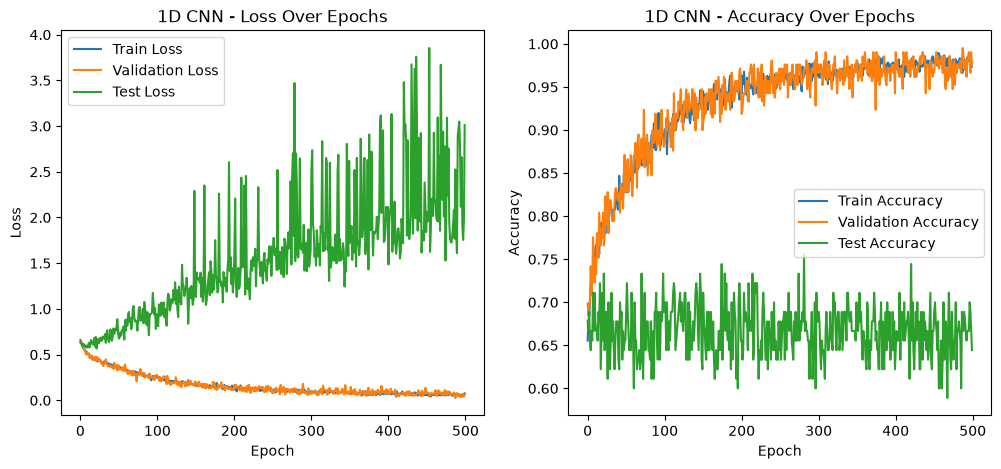

In [7]:
class CNN1DTrainer:
    def __init__(self, input_dim, num_filters=32, kernel_size=3, dropout=0.3, lr=0.001, k_folds=5, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._build_model(input_dim, num_filters, kernel_size, dropout).to(self.device)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.k_folds = k_folds

        self.train_losses, self.val_losses, self.test_losses = [], [], []
        self.train_accs, self.val_accs, self.test_accs = [], [], []

    class CNN1D(nn.Module):
        def __init__(self, input_dim, num_filters=32, kernel_size=3, dropout=0.3):
            super().__init__()
            # Conv1d: (batch, channels=1, length=input_dim)
            self.conv1 = nn.Conv1d(in_channels=1, out_channels=num_filters, kernel_size=kernel_size, padding=1)
            self.bn1 = nn.BatchNorm1d(num_filters)
            self.pool1 = nn.MaxPool1d(kernel_size=2)
            
            self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters*2, kernel_size=kernel_size, padding=1)
            self.bn2 = nn.BatchNorm1d(num_filters*2)
            self.pool2 = nn.MaxPool1d(kernel_size=2)
            
            self.dropout = nn.Dropout(dropout)
            
            # Calculate flattened size after convolutions
            # input_dim -> pool1 (/ 2) -> pool2 (/ 2)
            flattened_size = (input_dim // 4) * (num_filters * 2)
            
            self.fc1 = nn.Linear(flattened_size, 64)
            self.fc2 = nn.Linear(64, 1)
            
        def forward(self, x):
            # x shape: (batch, input_dim) -> reshape to (batch, 1, input_dim)
            x = x.unsqueeze(1)
            
            # Conv block 1
            x = self.conv1(x)
            x = self.bn1(x)
            x = torch.relu(x)
            x = self.pool1(x)
            x = self.dropout(x)
            
            # Conv block 2
            x = self.conv2(x)
            x = self.bn2(x)
            x = torch.relu(x)
            x = self.pool2(x)
            x = self.dropout(x)
            
            # Flatten and FC layers
            x = x.flatten(1)
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.dropout(x)
            x = self.fc2(x)
            x = torch.sigmoid(x)
            return x

    def _build_model(self, input_dim, num_filters, kernel_size, dropout):
        return self.CNN1D(input_dim, num_filters, kernel_size, dropout)

    @staticmethod
    def compute_accuracy(y_true, y_pred):
        y_pred_labels = (y_pred >= 0.5).float()
        correct = (y_pred_labels == y_true).float().sum()
        return (correct / y_true.shape[0]).item()

    def fit(self, X_train, y_train, X_test, y_test, epochs=500):
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1).to(self.device)

        for epoch in range(epochs):
            skf = StratifiedKFold(n_splits=self.k_folds, shuffle=True, random_state=42)
            fold_train_losses, fold_val_losses = [], []
            fold_train_accs, fold_val_accs = [], []

            for train_idx, val_idx in skf.split(X_train_tensor, y_train):
                X_fold_train = X_train_tensor[train_idx].to(self.device)
                y_fold_train = y_train_tensor[train_idx].to(self.device)
                X_fold_val = X_train_tensor[val_idx].to(self.device)
                y_fold_val = y_train_tensor[val_idx].to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(X_fold_train)
                loss = self.criterion(outputs, y_fold_train)
                loss.backward()
                self.optimizer.step()

                fold_train_losses.append(loss.item())
                fold_train_accs.append(self.compute_accuracy(y_fold_train, outputs))

                with torch.no_grad():
                    val_outputs = self.model(X_fold_val)
                    val_loss = self.criterion(val_outputs, y_fold_val)
                    fold_val_losses.append(val_loss.item())
                    fold_val_accs.append(self.compute_accuracy(y_fold_val, val_outputs))

            self.train_losses.append(np.mean(fold_train_losses))
            self.val_losses.append(np.mean(fold_val_losses))
            self.train_accs.append(np.mean(fold_train_accs))
            self.val_accs.append(np.mean(fold_val_accs))

            with torch.no_grad():
                test_outputs = self.model(X_test_tensor)
                self.test_losses.append(self.criterion(test_outputs, y_test_tensor).item())
                self.test_accs.append(self.compute_accuracy(y_test_tensor, test_outputs))

            if (epoch+1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, "
                      f"Train Loss: {self.train_losses[-1]:.4f}, Val Loss: {self.val_losses[-1]:.4f}, Test Loss: {self.test_losses[-1]:.4f}, "
                      f"Train Acc: {self.train_accs[-1]:.4f}, Val Acc: {self.val_accs[-1]:.4f}, Test Acc: {self.test_accs[-1]:.4f}")

    def plot_metrics(self):
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.plot(self.test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('1D CNN - Loss Over Epochs')
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(self.train_accs, label='Train Accuracy')
        plt.plot(self.val_accs, label='Validation Accuracy')
        plt.plot(self.test_accs, label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('1D CNN - Accuracy Over Epochs')
        plt.legend()
        plt.show()

# Train 1D CNN
cnn_trainer = CNN1DTrainer(input_dim=X_train.shape[1], num_filters=32, kernel_size=3)
cnn_trainer.fit(X_train, y_train, X_test, y_test, epochs=500)
cnn_trainer.plot_metrics()

## Recurrent Neural Networks (RNNs)

### What is an RNN?

Recurrent Neural Networks are designed to process sequential data with temporal dependencies:
- Hidden state: Maintain information from previous timesteps
- Sequential processing: Process input one timestep at a time
- Backpropagation through time (BPTT): Gradients flow backward through the sequence

### RNN Variants

Vanilla RNN:
- Simplest form but suffer from vanishing gradients on long sequences
- Formula: h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)

LSTM (Long Short-Term Memory):
- Solve vanishing gradient problem with gating mechanisms
- Input gate: Control what new info enters the cell
- Forget gate: Control what info is discarded
- Output gate: Control what info is output

GRU (Gated Recurrent Unit):
- Simpler than LSTM with only 2 gates (reset + update)
- Similar performance with fewer parameters

### Why RNNs for Heart Failure?

Heart failure data can be viewed as a time series:
- Sequential patient records over time
- Earlier measurements influence predictions
- RNNs naturally capture temporal patterns

## RNN Deep Dive: From Vanilla RNNs to Transformers

### The Sequence Modeling Problem

Challenge: Process variable-length sequences where order matters

- Text: "The cat sat on the mat" (sequential order critical)
- Time series: Stock prices over time (past prices predict future)
- Speech: Audio frames depend on previous frames
- DNA: Sequences of nucleotides

Why not just use MLPs?
- MLPs have fixed input size
- No way to handle variable-length sequences
- No notion of "time" or sequence order

### Vanilla RNN (Simplest Form)

Equations:
```
h_t = tanh(W_ih * x_t + W_hh * h_{t-1} + b_h)
y_t = W_hy * h_t + b_y
```

Where:
- h_t = hidden state at time t (memory)
- x_t = input at time t
- W_ih, W_hh, W_hy = weight matrices (shared across time)

Advantage: Single weight matrix applied to all timesteps (parameter sharing)

Problem: Vanishing/exploding gradients through time

When backpropagating through T timesteps:
```
dh_t/dh_{t-1} = W_hh^T · tanh'(...)
```

For deep sequences (large T), this product becomes:
- Very small: dL/dh_0 ≈ 0 (vanishing gradients)
- Very large: dL/dh_0 → ∞ (exploding gradients)

### LSTM: Solution via Gating

Key Idea: Use multiplicative gates to control information flow:

```
Forget gate:  f_t = σ(W_f·[h_{t-1}, x_t] + b_f)  ∈ [0,1]
Input gate:   i_t = σ(W_i·[h_{t-1}, x_t] + b_i)  ∈ [0,1]
Candidate:    C̃_t = tanh(W_c·[h_{t-1}, x_t] + b_c)
Cell state:   C_t = f_t ⊙ C_{t-1} + i_t ⊙ C̃_t
Output gate:  o_t = σ(W_o·[h_{t-1}, x_t] + b_o)  ∈ [0,1]
Hidden state: h_t = o_t ⊙ tanh(C_t)
```

Why this works:
- Cell state C_t has path with only addition (no squashing)
- Gradients flow through f_t gate: if f_t ≈ 1, gradient ≈ 1 (no vanishing)
- If f_t ≈ 0, older information is forgotten (selective retention)

### GRU: Simpler Alternative

Combine forget and input gates into single "update gate":

```
Reset gate:  r_t = σ(W_r·[h_{t-1}, x_t] + b_r)
Update gate: z_t = σ(W_z·[h_{t-1}, x_t] + b_z)
Candidate:   h̃_t = tanh(W·[r_t ⊙ h_{t-1}, x_t] + b)
Hidden:      h_t = (1-z_t) ⊙ h_{t-1} + z_t ⊙ h̃_t
```

- Fewer parameters than LSTM (2 gates vs 3)
- Similar performance in most tasks
- Preferred when data is limited

### RNN Applications & Variants

| Task | Architecture | Notes |
|---|---|---|
| Classification | Many-to-one (use final h_T) | Sentiment, health risk prediction |
| Sequence labeling | Many-to-many (output per step) | Named entity recognition, POS tagging |
| Seq2Seq | Many-to-many (encoder-decoder) | Machine translation, question answering |
| Language modeling | Many-to-many (predict next token) | Text generation, next word prediction |

### Attention Mechanism (2014)

Problem: Encoder-decoder for long sequences loses early information

Solution: Allow decoder to "attend to" relevant input positions

```
Attention(Q, K, V) = softmax(Q·K^T / √d_k) · V
```

- Q = Query (decoder state): "What do I need?"
- K = Key (encoder states): "What can I offer?"
- V = Value (encoder states): "Here's the actual info"
- softmax gives weights α ∈ [0,1] summing to 1

### Transformer (2017): Self-Attention Without RNNs

Key Innovation: Attention can work without recurrence:
- Each position attends to all other positions in parallel
- No sequential dependency → massive parallelization
- Led to BERT, GPT, and modern language models

Attention mechanism advantages:
- Solve long-range dependency problem (better than RNNs)
- Parallel computation (faster training)
- Interpretable: attention weights show which inputs matter

Epoch 50/500, Train Loss: 0.3547, Val Loss: 0.3456, Test Loss: 0.7228, Train Acc: 0.8625, Val Acc: 0.8613, Test Acc: 0.7444
Epoch 100/500, Train Loss: 0.2140, Val Loss: 0.2197, Test Loss: 1.2493, Train Acc: 0.9187, Val Acc: 0.9044, Test Acc: 0.7111
Epoch 150/500, Train Loss: 0.1378, Val Loss: 0.1430, Test Loss: 1.9359, Train Acc: 0.9366, Val Acc: 0.9332, Test Acc: 0.7333
Epoch 200/500, Train Loss: 0.0943, Val Loss: 0.0887, Test Loss: 2.2581, Train Acc: 0.9605, Val Acc: 0.9619, Test Acc: 0.7444
Epoch 250/500, Train Loss: 0.0625, Val Loss: 0.0544, Test Loss: 3.2401, Train Acc: 0.9821, Val Acc: 0.9762, Test Acc: 0.7556
Epoch 300/500, Train Loss: 0.0365, Val Loss: 0.0279, Test Loss: 5.1545, Train Acc: 0.9892, Val Acc: 0.9905, Test Acc: 0.7111
Epoch 350/500, Train Loss: 0.0351, Val Loss: 0.0694, Test Loss: 5.0174, Train Acc: 0.9845, Val Acc: 0.9810, Test Acc: 0.7111
Epoch 400/500, Train Loss: 0.0366, Val Loss: 0.0311, Test Loss: 4.0770, Train Acc: 0.9869, Val Acc: 0.9905, Test Acc: 0.7222
E

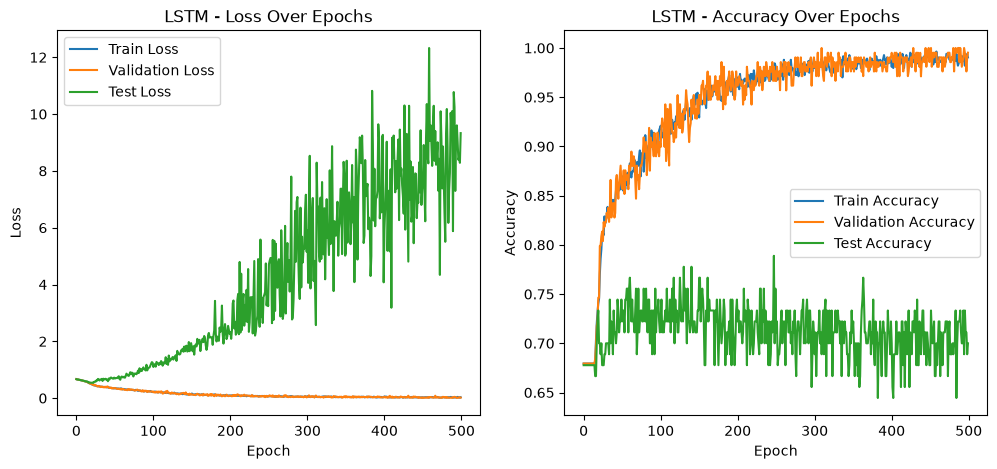

In [8]:
class LSTMTrainer:
    def __init__(self, input_dim, hidden_size=32, num_layers=2, dropout=0.3, lr=0.001, k_folds=5, device=None):
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = self._build_model(input_dim, hidden_size, num_layers, dropout).to(self.device)
        self.criterion = nn.BCELoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.k_folds = k_folds

        self.train_losses, self.val_losses, self.test_losses = [], [], []
        self.train_accs, self.val_accs, self.test_accs = [], [], []

    class LSTMNet(nn.Module):
        def __init__(self, input_dim, hidden_size=32, num_layers=2, dropout=0.3):
            super().__init__()
            # LSTM: (batch, seq_len, input_dim) -> (batch, seq_len, hidden_size)
            self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_size, 
                               num_layers=num_layers, dropout=dropout, batch_first=True)
            self.fc1 = nn.Linear(hidden_size, 64)
            self.fc2 = nn.Linear(64, 1)
            self.dropout = nn.Dropout(dropout)
            
        def forward(self, x):
            # x shape: (batch, input_dim)
            # Reshape to (batch, seq_len=1, input_dim) for LSTM
            x = x.unsqueeze(1)
            
            # LSTM forward pass
            lstm_out, (h_n, c_n) = self.lstm(x)
            # Use final hidden state: h_n[-1] is (batch, hidden_size)
            x = h_n[-1]
            
            # FC layers
            x = self.fc1(x)
            x = torch.relu(x)
            x = self.dropout(x)
            x = self.fc2(x)
            x = torch.sigmoid(x)
            return x

    def _build_model(self, input_dim, hidden_size, num_layers, dropout):
        return self.LSTMNet(input_dim, hidden_size, num_layers, dropout)

    @staticmethod
    def compute_accuracy(y_true, y_pred):
        y_pred_labels = (y_pred >= 0.5).float()
        correct = (y_pred_labels == y_true).float().sum()
        return (correct / y_true.shape[0]).item()

    def fit(self, X_train, y_train, X_test, y_test, epochs=500):
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
        X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(self.device)
        y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1).to(self.device)

        for epoch in range(epochs):
            skf = StratifiedKFold(n_splits=self.k_folds, shuffle=True, random_state=42)
            fold_train_losses, fold_val_losses = [], []
            fold_train_accs, fold_val_accs = [], []

            for train_idx, val_idx in skf.split(X_train_tensor, y_train):
                X_fold_train = X_train_tensor[train_idx].to(self.device)
                y_fold_train = y_train_tensor[train_idx].to(self.device)
                X_fold_val = X_train_tensor[val_idx].to(self.device)
                y_fold_val = y_train_tensor[val_idx].to(self.device)

                self.optimizer.zero_grad()
                outputs = self.model(X_fold_train)
                loss = self.criterion(outputs, y_fold_train)
                loss.backward()
                self.optimizer.step()

                fold_train_losses.append(loss.item())
                fold_train_accs.append(self.compute_accuracy(y_fold_train, outputs))

                with torch.no_grad():
                    val_outputs = self.model(X_fold_val)
                    val_loss = self.criterion(val_outputs, y_fold_val)
                    fold_val_losses.append(val_loss.item())
                    fold_val_accs.append(self.compute_accuracy(y_fold_val, val_outputs))

            self.train_losses.append(np.mean(fold_train_losses))
            self.val_losses.append(np.mean(fold_val_losses))
            self.train_accs.append(np.mean(fold_train_accs))
            self.val_accs.append(np.mean(fold_val_accs))

            with torch.no_grad():
                test_outputs = self.model(X_test_tensor)
                self.test_losses.append(self.criterion(test_outputs, y_test_tensor).item())
                self.test_accs.append(self.compute_accuracy(y_test_tensor, test_outputs))

            if (epoch+1) % 50 == 0:
                print(f"Epoch {epoch+1}/{epochs}, "
                      f"Train Loss: {self.train_losses[-1]:.4f}, Val Loss: {self.val_losses[-1]:.4f}, Test Loss: {self.test_losses[-1]:.4f}, "
                      f"Train Acc: {self.train_accs[-1]:.4f}, Val Acc: {self.val_accs[-1]:.4f}, Test Acc: {self.test_accs[-1]:.4f}")

    def plot_metrics(self):
        plt.figure(figsize=(12,5))
        plt.subplot(1,2,1)
        plt.plot(self.train_losses, label='Train Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        plt.plot(self.test_losses, label='Test Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('LSTM - Loss Over Epochs')
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(self.train_accs, label='Train Accuracy')
        plt.plot(self.val_accs, label='Validation Accuracy')
        plt.plot(self.test_accs, label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.title('LSTM - Accuracy Over Epochs')
        plt.legend()
        plt.show()

# Train LSTM
lstm_trainer = LSTMTrainer(input_dim=X_train.shape[1], hidden_size=32, num_layers=2)
lstm_trainer.fit(X_train, y_train, X_test, y_test, epochs=500)
lstm_trainer.plot_metrics()

## Model Comparison (MLP vs CNN vs LSTM)

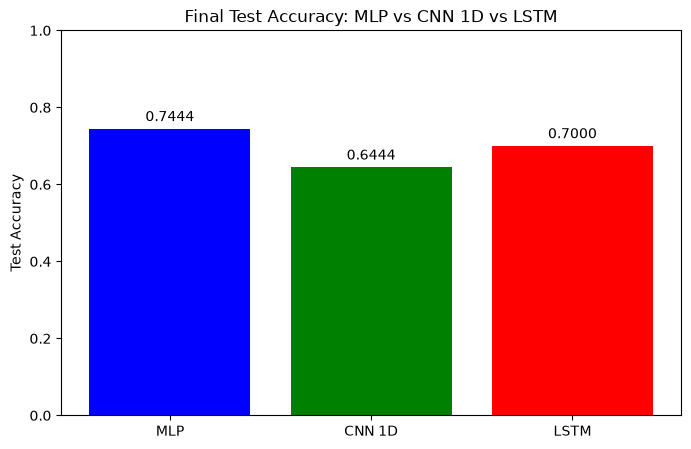

Final Test Accuracies:
  MLP: 0.7444
  CNN 1D: 0.6444
  LSTM: 0.7000

  Model  Final Test Accuracy                    Parameters                     Best For
   MLP             0.744444       Simple, fully connected        Tabular, no structure
CNN 1D             0.644444 Local patterns (convolutions) Spatial/sequential structure
  LSTM             0.700000  Temporal dependencies (LSTM)  Time series, long-term deps


In [9]:
# Compare test accuracies
models = ['MLP', 'CNN 1D', 'LSTM']
final_accuracies = [
    trainer.test_accs[-1],
    cnn_trainer.test_accs[-1],
    lstm_trainer.test_accs[-1]
]

plt.figure(figsize=(8, 5))
plt.bar(models, final_accuracies, color=['blue', 'green', 'red'])
plt.ylabel('Test Accuracy')
plt.title('Final Test Accuracy: MLP vs CNN 1D vs LSTM')
plt.ylim([0, 1])
for i, acc in enumerate(final_accuracies):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center')
plt.show()

print("Final Test Accuracies:")
for model, acc in zip(models, final_accuracies):
    print(f"  {model}: {acc:.4f}")

# Detailed comparison table
comparison_df = pd.DataFrame({
    'Model': models,
    'Final Test Accuracy': final_accuracies,
    'Parameters': [
        'Simple, fully connected',
        'Local patterns (convolutions)',
        'Temporal dependencies (LSTM)'
    ],
    'Best For': [
        'Tabular, no structure',
        'Spatial/sequential structure',
        'Time series, long-term deps'
    ]
})

print("\n", comparison_df.to_string(index=False))

## Practical Best Practices for Deep Learning

Based on Andrej Karpathy's "A Recipe for Training Neural Networks" and Google's ML best practices.

### 1. Start Simple, Add Complexity Gradually

```
Baseline MLP (2 layers):
    ↓ If underfitting
    ↓ Add hidden layer / more neurons
    ↓ Add regularization if overfitting
    ↓ Increase learning rate / epochs
    ↓ Add domain-specific architectures (CNN/RNN)
```

### 2. Data-First Approach

Before building a fancy model:
1. Understand your data
   - Visualize feature distributions
   - Check for outliers, missing values
   - Ensure correct train/val/test splits

2. Check if supervised learning is feasible
   - Can humans solve this task?
   - Is there signal in the data?
   - Test simple baseline (logistic regression)

3. Only then: try deep learning

### 3. Hyperparameter Selection Strategy

Learning Rate (most important):
- Too small: convergence is slow
- Too large: loss oscillates or diverges
- Start with lr=0.001, adjust based on loss curves

Batch size:
- Small (16-32): noisy gradients, act as regularizer
- Large (256+): cleaner gradients, might get stuck in sharp minima
- Sweet spot: 32-128 for most problems

Number of Layers & Units:
- Start with 1-2 hidden layers
- Double hidden layer size before doubling depth
- For N features, try 2-4× features in hidden layer

Dropout:
- Standard: p=0.5 for fully connected, p=0.3 for CNNs
- Reduce if underfitting, increase if overfitting

### 4. Training Checklist

- Normalize inputs (StandardScaler or MinMaxScaler)
- Use stratified splits (for imbalanced datasets)
- Plot loss/accuracy curves (detect overfitting early)
- Use validation set to tune hyperparameters
- Save best model (checkpoint on best validation loss)
- Evaluate only on test set (once at the end)

### 5. Debugging Common Issues

| Problem | Likely cause | Solution |
|---|---|---|
| Loss is NaN | Learning rate too high, exploding gradients | Decrease LR, add gradient clipping |
| Loss not decreasing | Learning rate too low, bad initialization | Increase LR, check data normalization |
| Train loss ↓ but val loss ↑ | Overfitting | Add dropout, L2 regularization, early stopping |
| Loss oscillates wildly | Batch size too small, LR too high | Increase batch size, decrease LR |
| Validation accuracy plateaus | Underfitting | Add layers, increase capacity, train longer |

### 6. Model Selection Strategy

For this heart failure dataset:

| Model | Best for | Complexity |
|---|---|---|
| Logistic Regression | Baseline | Low |
| Random Forest | Non-linear patterns | Medium |
| MLP (2-3 layers) | Moderate non-linearity | Medium |
| CNN | Local feature interactions | High |
| LSTM | Temporal patterns (if data is sequential) | Very high |

Recommendation: 
- Start with Logistic Regression → RF → MLP
- Only use CNN/LSTM if MLP underperforms and you have a good reason to believe the data has structure CNNs/LSTMs can exploit